In [72]:
# Libraries
import numpy as np
from tqdm import tqdm
from time import time
from PIL import Image

import torch
from torch.optim import Adam
from torch.nn import CrossEntropyLoss, Conv2d, AvgPool2d, BatchNorm2d, Dropout2d, LeakyReLU, Linear, Module
from torch.utils.data import DataLoader

from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [167]:
# Data Transformer
tfm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Create Dataset
TRAIN_ROOT = "C:/Users/lucre/Desktop/Università/Tirocinio e tesi/archive/Revitsone-5classes/train"
TEST_ROOT = "C:/Users/lucre/Desktop/Università/Tirocinio e tesi/archive/Revitsone-5classes/test"

train_ds = ImageFolder(TRAIN_ROOT, transform = tfm)
test_ds = ImageFolder(TEST_ROOT, transform = tfm)

# Length of Train and Test Datasets
len_train = len(train_ds)
len_test = len(test_ds)
# Index Mapping
train_ds.class_to_idx
{'other_activities': 0,
 'safe_driving': 1,
 'talking_phone': 2,
 'texting_phone': 3,
 'turning': 4}
# Data Loader
train_loader = DataLoader(train_ds, batch_size = 30, shuffle=True)
test_loader = DataLoader(test_ds, batch_size = 30, shuffle=True)

In [169]:
# Build Model
class DistractionCNN(Module):
    def __init__(self):
        super(DistractionCNN, self).__init__()
        self.conv = Conv2d(in_channels=3, out_channels=8, kernel_size=(3,3), stride=1, padding=1)
        self.pool = AvgPool2d(kernel_size=(3,3), stride=1)
        self.relu = LeakyReLU()
        self.bn = BatchNorm2d(num_features=8)
        self.drop = Dropout2d(p=0.3)
        self.fc = Linear(in_features=8*126*126, out_features=5)
        
    def forward(self, X):
        output = self.conv(X)
        output = self.pool(output)
        output = self.relu(output)
        output = self.bn(output)
        output = self.drop(output)
#         print(output.shape)
        output = output.view(-1, 8*126*126)
        output = self.fc(output)
        return output

In [171]:
# Define Model and Migrate to GPU
model = DistractionCNN().to(device)
# Optimiser
optimiser = Adam(model.parameters(), lr=1e-4, weight_decay=0.0001)

# Loss Function
loss_fn = CrossEntropyLoss()

In [173]:
for epoch in range(25):
    start = time()
    train_acc = 0
    test_acc = 0

# Train
    model.train()
    with tqdm(train_loader, unit="batch") as tepoch:
        for xtrain, ytrain in tepoch:
            optimiser.zero_grad()
            xtrain = xtrain.to(device)
            train_prob = model(xtrain)
            train_prob = train_prob.cpu()
            train_loss = loss_fn(train_prob, ytrain)
            train_loss.backward()
            optimiser.step()
            # END TRAIN
            train_pred = torch.max(train_prob, 1).indices
            train_acc += int(torch.sum(train_pred == ytrain))
            
        train_epoch_accuracy = train_acc / len_train

# Evaluate
    model.eval()
    with torch.no_grad():
        for xtest, ytest in test_loader:
            xtest = xtest.to(device)
            test_prob = model(xtest)
            test_prob = test_prob.cpu()
            test_loss = loss_fn(test_prob, ytest)
            test_pred = torch.max(test_prob, 1).indices
            test_acc += int(torch.sum(test_pred == ytest))
        
        test_epoch_accuracy = test_acc / len_test
    
    end = time()
    
    diff = end - start
    
    print(f"Epoch: {epoch+1}, Time: {diff}\nTr_loss: {train_loss}, Test_loss: {test_loss}\n,Tr_acc:{train_epoch_accuracy}, Test_acc: {test_epoch_accuracy}")

100%|██████████| 287/287 [01:34<00:00,  3.05batch/s]


Epoch: 1, Time: 112.3503406047821
Tr_loss: 0.810981273651123, Test_loss: 1.294918179512024
,Tr_acc:0.47914003486345147, Test_acc: 0.6514445479962722


100%|██████████| 287/287 [01:40<00:00,  2.84batch/s]


Epoch: 2, Time: 119.31245970726013
Tr_loss: 0.9352751970291138, Test_loss: 0.8834689259529114
,Tr_acc:0.6368390470656595, Test_acc: 0.7441752096924511


100%|██████████| 287/287 [01:37<00:00,  2.94batch/s]


...

Epoch: 23, Time: 187.85462760925293
Tr_loss: 0.08801423758268356, Test_loss: 0.09692633152008057
,Tr_acc:0.8615920976176642, Test_acc: 0.9231127679403541


100%|██████████| 287/287 [02:06<00:00,  2.27batch/s]


Epoch: 24, Time: 148.44850635528564
Tr_loss: 1.138867974281311, Test_loss: 0.21563178300857544
,Tr_acc:0.8653108657757118, Test_acc: 0.9175209692451072


100%|██████████| 287/287 [02:01<00:00,  2.36batch/s]


Epoch: 25, Time: 146.76776218414307
Tr_loss: 0.3887421786785126, Test_loss: 0.004059324041008949
,Tr_acc:0.872748402091807, Test_acc: 0.9245107176141659


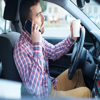

Model Pred: 0
Interpretation: Other activities


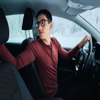

Model Pred: 2
Interpretation: Talking phone


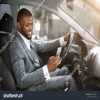

Model Pred: 1
Interpretation: Safe driving


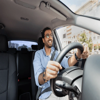

Model Pred: 3
Interpretation: Texting phone


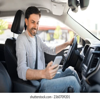

Model Pred: 4
Interpretation: Turning


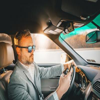

Model Pred: 1
Interpretation: Safe driving


In [175]:
# Image Samples
custom_images_path = "C:/Users/lucre/Desktop/Università/Tirocinio e tesi/archive"
sample_1 = custom_images_path + "/photo_2024-12-22_17-02-32.jpg"
sample_2 = custom_images_path + "/istockphoto-1302070223-612x612.jpg"
sample_3 = custom_images_path + "/images.jpg"
sample_4 = custom_images_path + "/joyful-indian-man-driving-car-600nw-2015511689.jpg"
sample_5 = custom_images_path + "/happy-handsome-millennial-guy-driver-260nw-2360709201.png"
sample_6 = custom_images_path + "/AdobeStock_195417278_0.jpg"

sample_list = [sample_1,sample_2,sample_3,sample_4,sample_5,sample_6]
# Model Performance
for img_path in sample_list:
    img = Image.open(img_path)
    display(img.resize((100, 100)))
    img_tensor = tfm(img)
    img_tensor = img_tensor[np.newaxis, :]
    img_tensor = img_tensor.to(device)
    prob = model(img_tensor)
    pred = torch.max(prob, 1).indices
    pred = pred.item()
    if pred == 0:
        print(f"Model Pred: {pred}\nInterpretation: Other activities")
    elif pred == 1:
        print(f"Model Pred: {pred}\nInterpretation: Safe driving")
    elif pred == 2:
        print(f"Model Pred: {pred}\nInterpretation: Talking phone")
    elif pred == 3:
        print(f"Model Pred: {pred}\nInterpretation: Texting phone")
    else:
        print(f"Model Pred: {pred}\nInterpretation: Turning")
        
    print("===============================================================")